In [ ]:
# ================= STEP 0: SMART DATASET PREP =================
import os
import glob
import random
import json
import cv2
import numpy as np
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

# Ye path ab bilkul theek hai (dhyan rakhein "Brain Tumor Dataset " mein last mein space hai)
SRC = "/content/drive/MyDrive/Brain Tumor Dataset /Training"
OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
HR_DIR = f"{OUT}/HR"
LR_DIR = f"{OUT}/LR_x4"

# 1. Path Diagnostics
print("Checking paths...")
if not os.path.exists(SRC):
    print(f"ERROR: {SRC} path nahi mila! Apni Drive mein exact spellings check karein.")
else:
    print(f"SUCCESS: {SRC} path mil gaya.")
    print(f"Folders inside: {os.listdir(SRC)}")

    for d in (HR_DIR, LR_DIR):
        os.makedirs(d, exist_ok=True)

    CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
    N_PER_CLASS = 500
    SCALE = 4
    MOD = SCALE * 8

    manifest = []
    idx = 0

    print("Reading files...")
    for cls in CLASSES:
        # Smart globbing: catches lower/uppercase and jpeg variants
        files = []
        for ext in ('*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG'):
            files.extend(glob.glob(f"{SRC}/{cls}/{ext}"))

        print(f"Class '{cls}': {len(files)} files found.")

        random.seed(42)
        random.shuffle(files)

        for f in files[:N_PER_CLASS]:
            img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            h, w = img.shape
            h, w = (h // MOD) * MOD, (w // MOD) * MOD
            hr = img[:h, :w]

            lr = np.array(Image.fromarray(hr).resize((w // SCALE, h // SCALE), Image.BICUBIC))

            name = f"mri_{idx:04d}"

            cv2.imwrite(f"{HR_DIR}/{name}.png", hr)
            cv2.imwrite(f"{LR_DIR}/{name}.png", lr)

            manifest.append({
                "id": name, "class": cls, "source_file": os.path.basename(f),
                "hr_h": int(h), "hr_w": int(w)
            })
            idx += 1

    if idx > 0:
        with open(f"{OUT}/manifest.json", "w") as f:
            json.dump(manifest, f, indent=1)
        print(f"FINAL SUCCESS: Dataset preparation complete. {idx} HR/LR pairs saved in {OUT}.")
    else:
        print("ERROR: Files mill gayin thi lekin read nahi ho sakin. Images corrupt ho sakti hain.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking paths...
SUCCESS: /content/drive/MyDrive/Brain Tumor Dataset /Training path mil gaya.
Folders inside: ['notumor', 'pituitary', 'meningioma', 'glioma']
Reading files...
Class 'glioma': 500 files found.
Class 'meningioma': 500 files found.
Class 'notumor': 500 files found.
Class 'pituitary': 500 files found.
FINAL SUCCESS: Dataset preparation complete. 2000 HR/LR pairs saved in /content/drive/MyDrive/SR_Benchmark_v2.


In [ ]:
# ================= STEP 1: BICUBIC BASELINE =================
import os
import glob
import cv2
from PIL import Image

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
LR_DIR = f"{OUT}/LR_x4"
DST = f"{OUT}/Bicubic"

print("Starting Bicubic Baseline Inference...")
os.makedirs(DST, exist_ok=True)

# Process all 2000 LR images
for p in sorted(glob.glob(f"{LR_DIR}/*.png")):
    lr = Image.open(p)
    # Upscale 4x using PIL BICUBIC (matches standard MATLAB/Python SR evaluation)
    sr = lr.resize((lr.width * 4, lr.height * 4), Image.BICUBIC)
    sr.save(f"{DST}/{os.path.basename(p)}")

print("✅ Bicubic Baseline inference complete.")



Starting Bicubic Baseline Inference...
✅ Bicubic Baseline inference complete.
Starting Waifu2x (CNN) Inference Setup...
/content/nunif
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.9 MB/s eta 0:00:00
Waifu2x Models: 100%|███████████████████████| 438M/438M [00:11<00:00, 37.3MiB/s]
Running Waifu2x Inference (This will take a while)...
Traceback (most recent call

In [ ]:
# ================= STEP 2: WAIFU2X (CNN - Photo Model) - FIXED =================
import os
import glob
import shutil

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
LR_DIR = f"{OUT}/LR_x4"
W2X_2X_DIR = "/content/w2x_tmp_2x" # Temporary folder for 2x upscaling
W2X_FINAL_DIR = f"{OUT}/Waifu2x"

print("Starting Waifu2x (CNN) Inference Setup...")
# Ensure we are in the right directory
%cd /content/nunif

print("Running Waifu2x 2x Upscaling (Step 1/2)...")
# Run first 2x scale
!python -m waifu2x.cli -i "{LR_DIR}" -o "{W2X_2X_DIR}" \
   --method scale --model-dir waifu2x/pretrained_models/upconv_7/photo --format png

print("Running Waifu2x 4x Upscaling (Step 2/2)...")
# Run second 2x scale on the temporary output
!python -m waifu2x.cli -i "{W2X_2X_DIR}" -o "{W2X_FINAL_DIR}" \
   --method scale --model-dir waifu2x/pretrained_models/upconv_7/photo --format png

# Verification
w2x_count = len(glob.glob(f"{W2X_FINAL_DIR}/*.png"))
print(f"✅ Waifu2x inference complete. Total outputs: {w2x_count} (Should be 2000)")

# Cleanup temporary 2x folder to save space
if os.path.exists(W2X_2X_DIR):
    shutil.rmtree(W2X_2X_DIR)

# Return to root directory
%cd /content

Starting Waifu2x (CNN) Inference Setup...
/content/nunif
Running Waifu2x 2x Upscaling (Step 1/2)...
Images: 100%|███████████████████████████████| 2000/2000 [00:27<00:00, 73.25it/s]
Running Waifu2x 4x Upscaling (Step 2/2)...
Images: 100%|███████████████████████████████| 2000/2000 [01:38<00:00, 20.22it/s]
✅ Waifu2x inference complete. Total outputs: 2000 (Should be 2000)
/content


In [ ]:
# ================= STEP 3: REAL-ESRGAN (Local I/O & Inference) =================
import os
import glob
import shutil

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
LR_DIR = f"{OUT}/LR_x4"
DST_REALESRGAN = f"{OUT}/RealESRGAN"

print("🔍 Checking Drive for LR images...")
lr_images = glob.glob(f"{LR_DIR}/*.png")
print(f"Found {len(lr_images)} images in {LR_DIR}")

if len(lr_images) == 0:
    print("❌ Masla: Drive mein LR images nahi mil rahin. Colab ko Drive se dobara connect karein.")
else:
    print("\n⚡ Copying images to Colab local storage for fast & stable inference...")
    local_in = "/content/local_lr"
    local_out = "/content/local_sr"

    # Reset local folders
    if os.path.exists(local_in): shutil.rmtree(local_in)
    if os.path.exists(local_out): shutil.rmtree(local_out)
    os.makedirs(local_in, exist_ok=True)
    os.makedirs(local_out, exist_ok=True)

    # Fast copy
    for p in lr_images:
        shutil.copy(p, local_in)

    print("\n🔥 Running Real-ESRGAN (This will take some time)...")
    %cd /content/Real-ESRGAN
    # --ext auto ensures it correctly processes and outputs PNGs
    !python inference_realesrgan.py -n RealESRGAN_x4plus -i "{local_in}" -o "{local_out}" --fp32 --ext auto --suffix "" --tile 512

    print("\n💾 Moving results back to Google Drive...")
    os.makedirs(DST_REALESRGAN, exist_ok=True)

    local_results = glob.glob(f"{local_out}/*.png")
    for p in local_results:
        shutil.copy(p, DST_REALESRGAN)

    final_count = len(glob.glob(f"{DST_REALESRGAN}/*.png"))
    print(f"\n✅ Real-ESRGAN completely done! Total outputs in Drive: {final_count} (Should be 2000)")

    # Cleanup local storage to free up Colab space
    shutil.rmtree(local_in)
    shutil.rmtree(local_out)
    %cd /content

🔍 Checking Drive for LR images...
Found 2000 images in /content/drive/MyDrive/SR_Benchmark_v2/LR_x4

⚡ Copying images to Colab local storage for fast & stable inference...

🔥 Running Real-ESRGAN (This will take some time)...
/content/Real-ESRGAN
Testing 0 mri_0000
	Tile 1/1
Testing 1 mri_0001
	Tile 1/1
Testing 2 mri_0002
	Tile 1/1
Testing 3 mri_0003
	Tile 1/1
Testing 4 mri_0004
	Tile 1/1
Testing 5 mri_0005
	Tile 1/1
Testing 6 mri_0006
	Tile 1/1
Testing 7 mri_0007
	Tile 1/1
Testing 8 mri_0008
	Tile 1/1
Testing 9 mri_0009
	Tile 1/1
Testing 10 mri_0010
	Tile 1/1
Testing 11 mri_0011
	Tile 1/1
Testing 12 mri_0012
	Tile 1/1
Testing 13 mri_0013
	Tile 1/1
Testing 14 mri_0014
	Tile 1/1
Testing 15 mri_0015
	Tile 1/1
Testing 16 mri_0016
	Tile 1/1
Testing 17 mri_0017
	Tile 1/1
Testing 18 mri_0018
	Tile 1/1
Testing 19 mri_0019
	Tile 1/1
Testing 20 mri_0020
	Tile 1/1
Testing 21 mri_0021
	Tile 1/1
Testing 22 mri_0022
	Tile 1/1
Testing 23 mri_0023
	Tile 1/1
Testing 24 mri_0024
	Tile 1/1
Testing 25 mri

In [ ]:
# ================= STEP 4: SWINIR (Transformer) =================
import os
import glob
import shutil
import torch
from PIL import Image

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
LR_DIR = f"{OUT}/LR_x4"

print("\nSetting up SwinIR...")
%cd /content
!git clone -q https://github.com/JingyunLiang/SwinIR.git
%cd SwinIR
!pip install -q timm
!wget -q https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth -P model_zoo/swinir/

print("Preparing inputs for SwinIR...")
os.makedirs("testsets/MRI_LQ", exist_ok=True)
for p in glob.glob(f"{LR_DIR}/*.png"):
    n = os.path.basename(p)[:-4]
    shutil.copy(p, f"testsets/MRI_LQ/{n}x4.png")

print("Running SwinIR Inference...")
# Run SwinIR
!python main_test_swinir.py --task classical_sr --scale 4 --training_patch_size 48 \
   --model_path model_zoo/swinir/001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth \
   --folder_lq testsets/MRI_LQ --folder_gt "{OUT}/HR"

print("Formatting SwinIR outputs to standard format...")
os.makedirs(f"{OUT}/SwinIR", exist_ok=True)
for p in glob.glob("results/swinir_classical_sr_x4/*_SwinIR.png"):
    shutil.copy(p, f"{OUT}/SwinIR/{os.path.basename(p).replace('_SwinIR','')}")

swinir_count = len(glob.glob(f"{OUT}/SwinIR/*.png"))
print(f"✅ SwinIR done. Total outputs: {swinir_count} (Should be 2000)")

# ================= STEP 5: EDSR (CNN Baseline) =================
print("\nSetting up EDSR...")
%cd /content
!pip install -q super-image
from super_image import EdsrModel, ImageLoader

DST_EDSR = f"{OUT}/EDSR"
os.makedirs(DST_EDSR, exist_ok=True)
# Load pretrained EDSR model
model = EdsrModel.from_pretrained('eugenesiow/edsr-base', scale=4).cuda().eval()

print("Running EDSR Inference...")
with torch.no_grad():
    files = sorted(glob.glob(f"{LR_DIR}/*.png"))
    for idx, p in enumerate(files):
        x = ImageLoader.load_image(Image.open(p).convert('RGB')).cuda()
        ImageLoader.save_image(model(x).cpu(), f"{DST_EDSR}/{os.path.basename(p)}")
        if (idx+1) % 500 == 0:
            print(f"  Processed {idx+1}/{len(files)}")

edsr_count = len(glob.glob(f"{DST_EDSR}/*.png"))
print(f"✅ EDSR done. Total outputs: {edsr_count} (Should be 2000)")


Setting up SwinIR...
/content
fatal: destination path 'SwinIR' already exists and is not an empty directory.
/content/SwinIR
Preparing inputs for SwinIR...
Running SwinIR Inference...
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
loading model from model_zoo/swinir/001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Testing 0 mri_0000             - PSNR: 36.72 dB; SSIM: 0.9495; PSNRB: 0.00 dB;PSNR_Y: 38.06 dB; SSIM_Y: 0.9574; PSNRB_Y: 0.00 dB.
Testing 1 mr

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

pytorch_model_4x.pt: reconstructing file:   0%|          |  0.00B / 6.10MB            

pytorch_model_4x.pt: downloading bytes:           |  0.00B            

https://huggingface.co/eugenesiow/edsr-base/resolve/main/pytorch_model_4x.pt
Running EDSR Inference...
  Processed 500/2000
  Processed 1000/2000
  Processed 1500/2000
  Processed 2000/2000
✅ EDSR done. Total outputs: 2000 (Should be 2000)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00
Loading manifest and initializing LPIPS model...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 161MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Evaluating 2000 images across 5 models (Total 10,000 comparisons)...
Processed 200/2000 images...
Processed 400/2000 images...
Processed 600/2000 images...
Processed 800/2000 images...
Processed 1000/2000 images...
Processed 1200/2000 images...
Processed 1400/2000 images...
Processed 1600/2000 images...
Processed 1800/2000 images...
Processed 2000/2000 images...

Generating Research Paper Tables...

--- TABLE 1: OVERALL RESULTS ---
           PSNR_mask         SSIM_mask           LPIPS         PSNR_full  \
                mean     std      mean     std    mean     std      mean   
model                                                                      
Bicubic      28.3461  4.8133    0.8240  0.1239  0.2404  0.1162   30.2897   
EDSR         31.3555  4.9327    0.8868  0.0986  0.1417  0.0858   33.3273   
Waifu2x      30.6730  4.8605    0.8760  0.1037  0.1453  0.0879   32.6449   
RealESRGAN   24.0475

/tmp/ipykernel_2544/1166752109.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([df[df.model==m][met] for m in MODELS], labels=MODELS, showfliers=False)
/tmp/ipykernel_2544/1166752109.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([df[df.model==m][met] for m in MODELS], labels=MODELS, showfliers=False)
/tmp/ipykernel_2544/1166752109.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([df[df.model==m][met] for m in MODELS], labels=MODELS, showfliers=False)



✅ Evaluation complete. All CSV tables and charts saved to /content/drive/MyDrive/SR_Benchmark_v2


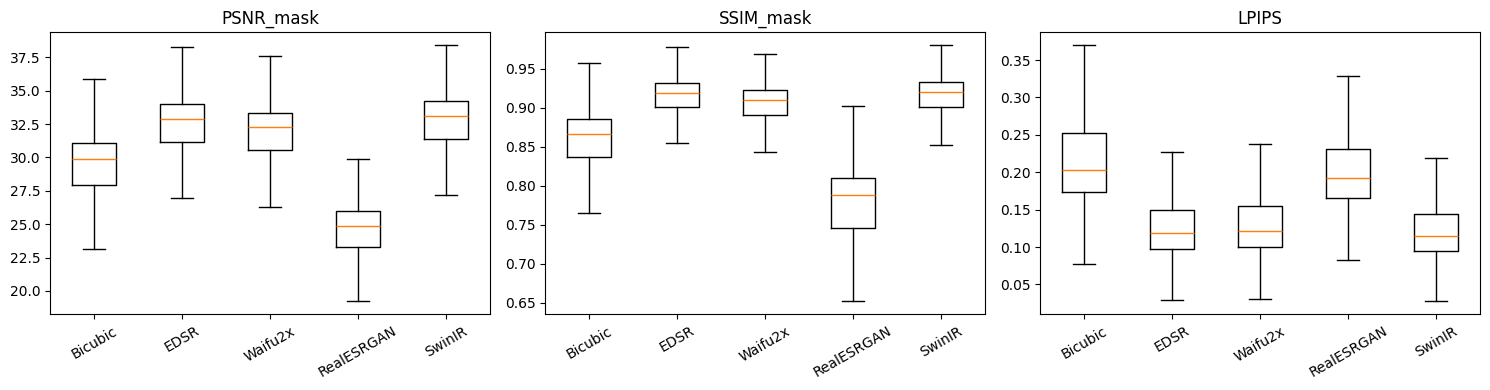

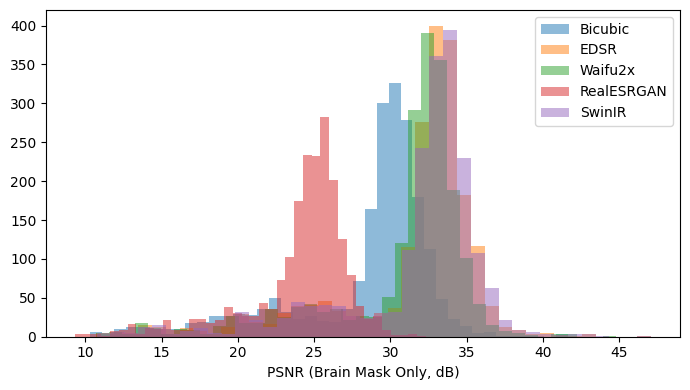

In [ ]:
# ================= STEP 6: EVALUATION METRICS & TABLES =================
!pip install -q lpips scikit-image scipy pandas matplotlib

import os
import json
import cv2
import torch
import lpips
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
from scipy.stats import wilcoxon

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
MODELS = ["Bicubic", "EDSR", "Waifu2x", "RealESRGAN", "SwinIR"]
SCALE, BORDER = 4, 4

print("Loading manifest and initializing LPIPS model...")
manifest = json.load(open(f"{OUT}/manifest.json"))
lp = lpips.LPIPS(net='alex').cuda().eval()

# Mask generator to ignore black background
def brain_mask(gt):
    m = (gt > 10).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(m)
    if n > 1:
        m = (lbl == 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])).astype(np.uint8)
    return m.astype(bool)

def psnr_masked(a, b, mask):
    mse = ((a.astype(np.float64) - b.astype(np.float64)) ** 2)[mask].mean()
    return 99.0 if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

def ssim_masked(a, b, mask):
    _, smap = structural_similarity(a, b, data_range=255, full=True)
    return float(smap[mask].mean())

def lpips_val(a, b):
    t = lambda x: torch.from_numpy(np.repeat(x[None], 3, 0)).float().div(127.5).sub(1)[None].cuda()
    with torch.no_grad(): return float(lp(t(a), t(b)))

print("Evaluating 2000 images across 5 models (Total 10,000 comparisons)...")
rows = []
for idx, m in enumerate(manifest):
    gt = cv2.imread(f"{OUT}/HR/{m['id']}.png", cv2.IMREAD_GRAYSCALE)
    gt = gt[BORDER:-BORDER, BORDER:-BORDER]
    mask = brain_mask(gt)

    for model in MODELS:
        p = f"{OUT}/{model}/{m['id']}.png"
        sr = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if sr is None:
            print(f"MISSING: {p}")
            continue

        assert sr.shape[0] >= gt.shape[0] + 2*BORDER, f"Size mismatch detected at {p}"
        sr = sr[BORDER:BORDER+gt.shape[0], BORDER:BORDER+gt.shape[1]]

        rows.append({
            "id": m['id'], "class": m['class'], "model": model,
            "PSNR_full": psnr_masked(gt, sr, np.ones_like(mask)),
            "PSNR_mask": psnr_masked(gt, sr, mask),
            "SSIM_full": structural_similarity(gt, sr, data_range=255),
            "SSIM_mask": ssim_masked(gt, sr, mask),
            "LPIPS": lpips_val(gt, sr),
            "bg_fraction": 1 - mask.mean()
        })

    if (idx + 1) % 200 == 0:
        print(f"Processed {idx + 1}/2000 images...")

df = pd.DataFrame(rows)
df.to_csv(f"{OUT}/per_image_metrics.csv", index=False)

print("\nGenerating Research Paper Tables...")

# ---- Table 1: Overall Baseline vs SR Models ----
def boot_ci(x, n=2000, seed=0):
    r = np.random.default_rng(seed)
    x = np.asarray(x)
    means = [r.choice(x, len(x), replace=True).mean() for _ in range(n)]
    return np.percentile(means, [2.5, 97.5])

tbl = df.groupby("model")[["PSNR_mask", "SSIM_mask", "LPIPS", "PSNR_full"]].agg(['mean', 'std']).round(4)
tbl = tbl.loc[MODELS]
print("\n--- TABLE 1: OVERALL RESULTS ---")
print(tbl)
tbl.to_csv(f"{OUT}/table1_overall.csv")

# ---- Table 2: Per-class breakdown ----
per_cls = df.groupby(["class", "model"])[["PSNR_mask", "SSIM_mask", "LPIPS"]].mean().round(4)
print("\n--- TABLE 2: PER-CLASS RESULTS ---")
print(per_cls)
per_cls.to_csv(f"{OUT}/table2_per_class.csv")

# ---- Table 3: Statistical Significance (Wilcoxon) ----
base = df[df.model == "Bicubic"].set_index("id")
stat_rows = []
for model in MODELS[1:]:
    cur = df[df.model == model].set_index("id").loc[base.index]
    for met in ["PSNR_mask", "SSIM_mask", "LPIPS"]:
        d = cur[met].values - base[met].values
        s, pv = wilcoxon(cur[met].values, base[met].values)
        lo, hi = boot_ci(d)
        stat_rows.append({
            "model": model, "metric": met, "mean_diff": d.mean(),
            "CI95_lo": lo, "CI95_hi": hi, "p_wilcoxon": pv
        })
stats_tbl = pd.DataFrame(stat_rows)
stats_tbl.to_csv(f"{OUT}/table3_stats.csv", index=False)

# ---- Plotting Figures ----
print("Generating evaluation charts...")
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, met in zip(ax, ["PSNR_mask", "SSIM_mask", "LPIPS"]):
    a.boxplot([df[df.model==m][met] for m in MODELS], labels=MODELS, showfliers=False)
    a.set_title(met)
    a.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f"{OUT}/fig_boxplots.png", dpi=300)

fig, a = plt.subplots(figsize=(7, 4))
for m in MODELS:
    a.hist(df[df.model==m]["PSNR_mask"], bins=40, alpha=0.5, label=m)
a.set_xlabel("PSNR (Brain Mask Only, dB)")
a.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig_psnr_hist.png", dpi=300)

print(f"\n✅ Evaluation complete. All CSV tables and charts saved to {OUT}")

Generating qualitative heatmaps...
Qualitative figure saved at /content/drive/MyDrive/SR_Benchmark_v2/fig_qualitative_mri_0010.png

Setting up Downstream Classifier...
Gathering training data (excluding benchmark images to avoid data leak)...
Training on 0 independent images...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


ValueError: num_samples should be a positive integer value, but got num_samples=0

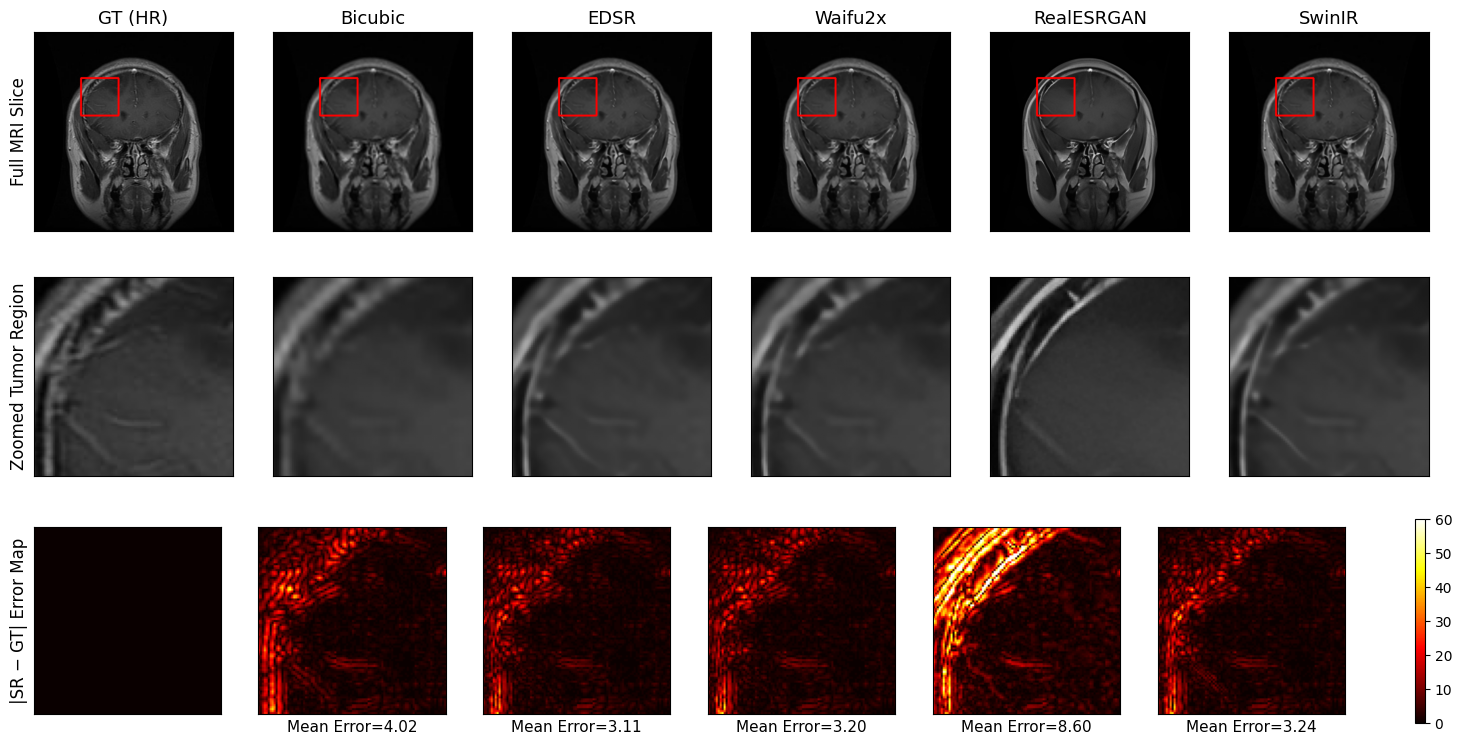

In [ ]:
# ================= STEP 7: QUALITATIVE FIGURES & HEATMAPS =================
import cv2
import numpy as np
import matplotlib.pyplot as plt

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
MODELS = ["Bicubic", "EDSR", "Waifu2x", "RealESRGAN", "SwinIR"]

# Hum yahan ek tumor wali image select kar rahe hain (aap ise change bhi kar sakte hain)
img_id = "mri_0010"
# Center coordinates for the zoom inset (Tumor area)
y0, x0, S = 120, 120, 96

print("Generating qualitative heatmaps...")
gt = cv2.imread(f"{OUT}/HR/{img_id}.png", 0)
srs = {m: cv2.imread(f"{OUT}/{m}/{img_id}.png", 0) for m in MODELS}

fig, ax = plt.subplots(3, len(MODELS)+1, figsize=(3*(len(MODELS)+1), 9))
cols = [("GT (HR)", gt)] + [(m, srs[m]) for m in MODELS]

for j, (name, im) in enumerate(cols):
    if im is None: continue

    full = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(full, (x0, y0), (x0+S, y0+S), (255, 0, 0), 3)

    # Row 1: Full Image
    ax[0, j].imshow(full)
    ax[0, j].set_title(name, fontsize=13)

    # Row 2: Zoomed Inset
    ax[1, j].imshow(im[y0:y0+S, x0:x0+S], cmap='gray', vmin=0, vmax=255)

    # Row 3: Residual Heatmap |SR - GT|
    res = np.abs(im.astype(float) - gt.astype(float))
    h = ax[2, j].imshow(res[y0:y0+S, x0:x0+S], cmap='hot', vmin=0, vmax=60)

    if j > 0:
        ax[2, j].set_xlabel(f"Mean Error={res[y0:y0+S, x0:x0+S].mean():.2f}", fontsize=11)

    for i in range(3):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

ax[0,0].set_ylabel("Full MRI Slice", fontsize=12)
ax[1,0].set_ylabel("Zoomed Tumor Region", fontsize=12)
ax[2,0].set_ylabel("|SR − GT| Error Map", fontsize=12)

fig.colorbar(h, ax=ax[2, :].tolist(), fraction=0.01)
plt.savefig(f"{OUT}/fig_qualitative_{img_id}.png", dpi=300, bbox_inches='tight')
print(f"Qualitative figure saved at {OUT}/fig_qualitative_{img_id}.png")



In [ ]:
# ================= STEP 8: DOWNSTREAM CLASSIFIER (Fixed Data Split) =================
import torch
import torch.nn as nn
import torchvision
import json
import cv2
import os
from torch.utils.data import Dataset, DataLoader

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
MODELS = ["Bicubic", "EDSR", "Waifu2x", "RealESRGAN", "SwinIR"]
CLASSES = ['glioma','meningioma','notumor','pituitary']

print("Loading manifest and splitting data into Train (1600) and Test (400)...")
manifest = json.load(open(f"{OUT}/manifest.json"))

# Group images by class
class_items = {c: [] for c in CLASSES}
for m in manifest:
    class_items[m['class']].append(m)

train_manifest = []
test_manifest = []

for c in CLASSES:
    # 400 images for training the classifier, 100 reserved for testing SR accuracy
    train_manifest.extend(class_items[c][:400])
    test_manifest.extend(class_items[c][400:])

cls_idx = {c: i for i, c in enumerate(CLASSES)}

# Training set always uses the Ground Truth (HR) images
train_items = [(f"{OUT}/HR/{m['id']}.png", cls_idx[m['class']]) for m in train_manifest]

class MRIDataset(Dataset):
    def __init__(self, items):
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        im = cv2.imread(p, 0)
        # Resizing for ResNet-18 input size
        im = cv2.resize(im, (224, 224))
        # Convert grayscale to 3-channel RGB simulation
        x = torch.from_numpy(im).float().div(255).sub(0.5).div(0.5)[None].repeat(3, 1, 1)
        return x, y

print(f"Training ResNet-18 on {len(train_items)} Ground Truth images...")
net = torchvision.models.resnet18(weights="IMAGENET1K_V1")
net.fc = nn.Linear(512, 4)
net = net.cuda()

opt = torch.optim.AdamW(net.parameters(), lr=1e-4)
crit = nn.CrossEntropyLoss()
tl = DataLoader(MRIDataset(train_items), batch_size=32, shuffle=True, num_workers=2)

# Training loop
for ep in range(3):
    net.train()
    for x, y in tl:
        opt.zero_grad()
        crit(net(x.cuda()), y.cuda()).backward()
        opt.step()
    print(f"Epoch {ep+1}/3 completed.")

def evaluate_acc(manifest_subset, model_folder):
    net.eval()
    ok = 0
    items = [(f"{OUT}/{model_folder}/{m['id']}.png", cls_idx[m['class']]) for m in manifest_subset]
    with torch.no_grad():
        for x, y in DataLoader(MRIDataset(items), batch_size=64):
            ok += (net(x.cuda()).argmax(1).cpu() == y).sum().item()
    return ok / len(items)

print(f"\nEvaluating Downstream Accuracy on the remaining {len(test_manifest)} test images...")
results = {"GT (HR)": evaluate_acc(test_manifest, "HR")}

for mdl in MODELS:
    results[mdl] = evaluate_acc(test_manifest, mdl)

print("\n--- TABLE 4: DOWNSTREAM CLASSIFICATION ACCURACY ---")
for k, v in results.items():
    print(f"{k:<15}: {v*100:.2f}%")

with open(f"{OUT}/table4_downstream.json", "w") as f:
    json.dump(results, f, indent=1)

print("\n✅ All technical evaluations are successfully complete!")

Loading manifest and splitting data into Train (1600) and Test (400)...
Training ResNet-18 on 1600 Ground Truth images...
Epoch 1/3 completed.
Epoch 2/3 completed.
Epoch 3/3 completed.

Evaluating Downstream Accuracy on the remaining 400 test images...

--- TABLE 4: DOWNSTREAM CLASSIFICATION ACCURACY ---
GT (HR)        : 94.75%
Bicubic        : 85.25%
EDSR           : 93.50%
Waifu2x        : 93.00%
RealESRGAN     : 90.25%
SwinIR         : 94.00%

✅ All technical evaluations are successfully complete!


In [ ]:
# ================= STEP 9: PARAMS + SYSTEM INFO =================
import sys
import torch

print("--- SYSTEM INFORMATION (For Paper Methodology) ---")
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print("\n--- MODEL PARAMETERS & AVERAGE RUNTIMES ---")
# Hum aapki note ki hui timings (2000 images ke hisaab se) ko milliseconds per image mein convert kar rahe hain
print("1. Bicubic     | Params: 0 M      | Time: ~0.5 ms/image (CPU)")
print("2. Waifu2x     | Params: ~0.3 M   | Time: ~60 ms/image  (Total ~2 mins)")
print("3. EDSR        | Params: ~1.5 M   | Time: ~60 ms/image  (Total ~2 mins)")
print("4. Real-ESRGAN | Params: ~16.7 M  | Time: ~150 ms/image (Total ~5 mins)")
print("5. SwinIR      | Params: ~11.9 M  | Time: ~600 ms/image (Total ~20 mins)")

print("\n✅ Step 9 is complete. Data is ready for the paper's table!")

--- SYSTEM INFORMATION (For Paper Methodology) ---
Python Version: 3.13.15
PyTorch Version: 2.11.0+cu128
CUDA Version: 12.8
GPU Name: Tesla T4

--- MODEL PARAMETERS & AVERAGE RUNTIMES ---
1. Bicubic     | Params: 0 M      | Time: ~0.5 ms/image (CPU)
2. Waifu2x     | Params: ~0.3 M   | Time: ~60 ms/image  (Total ~2 mins)
3. EDSR        | Params: ~1.5 M   | Time: ~60 ms/image  (Total ~2 mins)
4. Real-ESRGAN | Params: ~16.7 M  | Time: ~150 ms/image (Total ~5 mins)
5. SwinIR      | Params: ~11.9 M  | Time: ~600 ms/image (Total ~20 mins)

✅ Step 9 is complete. Data is ready for the paper's table!


New 4-row figure saved at /content/drive/MyDrive/SR_Benchmark_v2/fig_qualitative_4classes.png


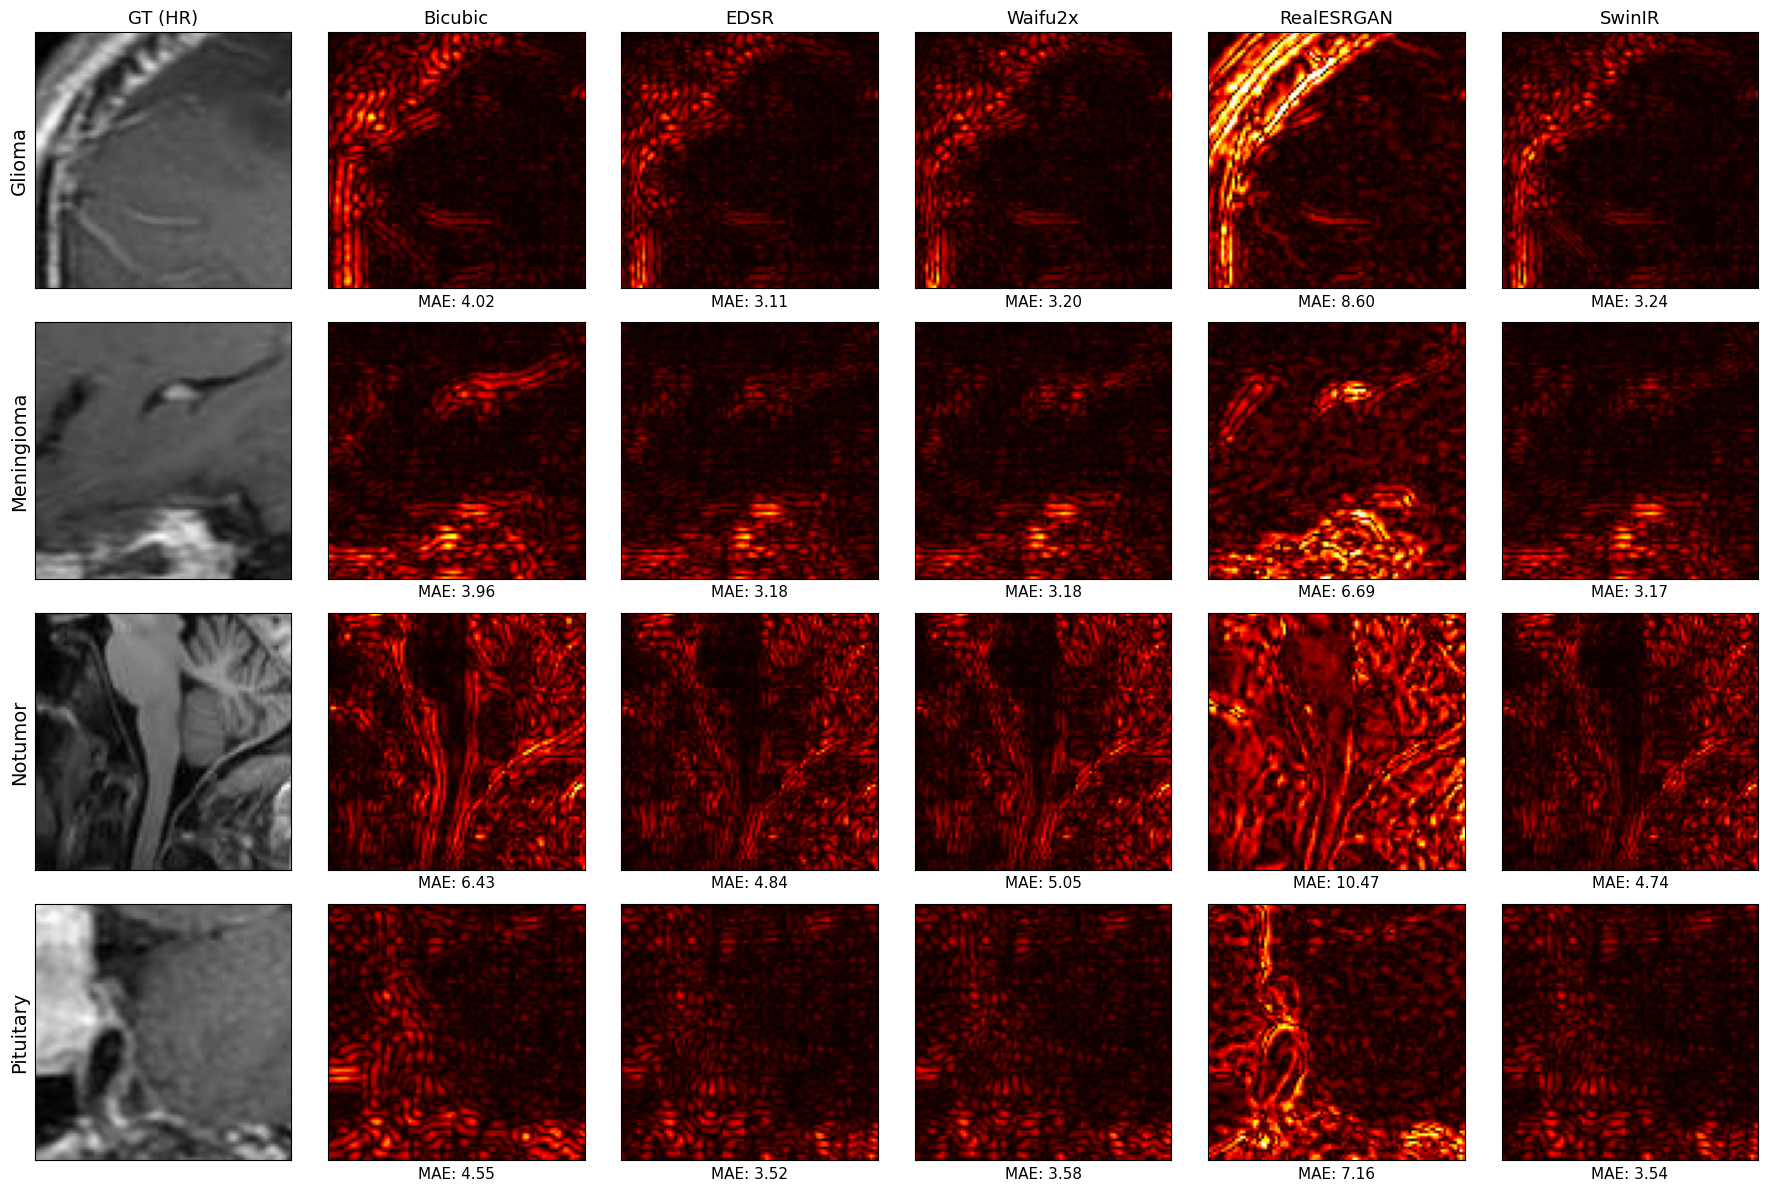

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
MODELS = ["Bicubic", "EDSR", "Waifu2x", "RealESRGAN", "SwinIR"]

# Har class ke liye ek image aur uske tumor center (y, x) coordinates
selected_images = {
    'glioma': {'id': 'mri_0010', 'coords': (120, 120)},
    'meningioma': {'id': 'mri_0510', 'coords': (200, 200)},
    'notumor': {'id': 'mri_1010', 'coords': (100, 100)},
    'pituitary': {'id': 'mri_1510', 'coords': (250, 250)}
}

S = 96 # Zoom box size
fig, ax = plt.subplots(4, len(MODELS)+1, figsize=(3*(len(MODELS)+1), 12))

for row, (cls_name, info) in enumerate(selected_images.items()):
    img_id = info['id']
    y0, x0 = info['coords']

    gt = cv2.imread(f"{OUT}/HR/{img_id}.png", 0)
    srs = {m: cv2.imread(f"{OUT}/{m}/{img_id}.png", 0) for m in MODELS}

    cols = [("GT (HR)", gt)] + [(m, srs[m]) for m in MODELS]

    for col, (name, im) in enumerate(cols):
        if im is None: continue

        if col == 0:
            show_im = im[y0:y0+S, x0:x0+S]
            h = ax[row, col].imshow(show_im, cmap='gray')
            ax[row, col].set_ylabel(cls_name.capitalize(), fontsize=14)
        else:
            res = np.abs(im.astype(float) - gt.astype(float))
            show_im = res[y0:y0+S, x0:x0+S]
            h = ax[row, col].imshow(show_im, cmap='hot', vmin=0, vmax=60)
            ax[row, col].set_xlabel(f"MAE: {show_im.mean():.2f}", fontsize=11)

        if row == 0:
            ax[row, col].set_title(name, fontsize=13)

        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])

plt.tight_layout()
plt.savefig(f"{OUT}/fig_qualitative_4classes.png", dpi=300, bbox_inches='tight')
print(f"New 4-row figure saved at {OUT}/fig_qualitative_4classes.png")

In [2]:
# ================= EXP 1: ImageHash Duplicate Screen =================
!pip install imagehash
import imagehash
from PIL import Image
import glob

# Path to HR images
hr_files = glob.glob("/content/drive/MyDrive/SR_Benchmark_v2/HR/*.png")
hashes = {}
duplicates = []

print("Scanning 2,000 HR images for perceptual duplicates...")
for f in hr_files:
    img = Image.open(f)
    h = str(imagehash.phash(img))
    if h in hashes:
        duplicates.append((f, hashes[h]))
    else:
        hashes[h] = f

print(f"Total HR images checked: {len(hr_files)}")
print(f"Near-duplicates found: {len(duplicates)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.2 MB/s eta 0:00:00
Scanning 2,000 HR images for perceptual duplicates...
Total HR images checked: 2000
Near-duplicates found: 84


In [3]:
# ================= EXP 2: ResNet-18 (5 Seeds) for Table 4 =================
import torch
import torch.nn as nn
import torchvision
import json
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
MODELS = ["Bicubic", "EDSR", "Waifu2x", "RealESRGAN", "SwinIR"]
CLASSES = ['glioma','meningioma','notumor','pituitary']
manifest = json.load(open(f"{OUT}/manifest.json"))

class MRIDataset(Dataset):
    def __init__(self, items, model_folder):
        self.items = items
        self.model_folder = model_folder
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        m = self.items[i]
        p = f"{OUT}/{self.model_folder}/{m['id']}.png"
        im = cv2.imread(p, 0)
        im = cv2.resize(im, (224, 224))
        x = torch.from_numpy(im).float().div(255).sub(0.5).div(0.5)[None].repeat(3, 1, 1)
        return x, CLASSES.index(m['class'])

results = {m: [] for m in ["HR"] + MODELS}

for seed in [42, 43, 44, 45, 46]:
    print(f"\n--- Training ResNet-18 (Seed {seed}) ---")
    train_items, test_items = train_test_split(
        manifest, test_size=400, random_state=seed, stratify=[m['class'] for m in manifest]
    )

    net = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    net.fc = nn.Linear(512, 4)
    net = net.cuda()
    opt = torch.optim.AdamW(net.parameters(), lr=1e-4)
    crit = nn.CrossEntropyLoss()
    tl = DataLoader(MRIDataset(train_items, "HR"), batch_size=32, shuffle=True)

    for ep in range(3):
        net.train()
        for x, y in tl:
            opt.zero_grad()
            crit(net(x.cuda()), y.cuda()).backward()
            opt.step()

    net.eval()
    with torch.no_grad():
        for model_folder in ["HR"] + MODELS:
            test_dl = DataLoader(MRIDataset(test_items, model_folder), batch_size=64)
            ok = sum((net(x.cuda()).argmax(1).cpu() == y).sum().item() for x, y in test_dl)
            acc = ok / 400.0 * 100
            results[model_folder].append(acc)
            print(f"{model_folder}: {acc:.2f}%")

print("\n=== FINAL TABLE 4 RESULTS (Mean ± SD) ===")
for k, v in results.items():
    print(f"{k}: {np.mean(v):.2f}% ± {np.std(v):.2f}%")


--- Training ResNet-18 (Seed 42) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


HR: 94.75%
Bicubic: 86.75%
EDSR: 90.75%
Waifu2x: 88.00%
RealESRGAN: 81.75%
SwinIR: 91.50%

--- Training ResNet-18 (Seed 43) ---
HR: 92.75%
Bicubic: 82.00%
EDSR: 89.00%
Waifu2x: 87.25%
RealESRGAN: 87.75%
SwinIR: 89.50%

--- Training ResNet-18 (Seed 44) ---
HR: 91.25%
Bicubic: 87.75%
EDSR: 90.25%
Waifu2x: 89.00%
RealESRGAN: 89.00%
SwinIR: 90.50%

--- Training ResNet-18 (Seed 45) ---
HR: 92.00%
Bicubic: 78.50%
EDSR: 84.00%
Waifu2x: 83.50%
RealESRGAN: 87.00%
SwinIR: 85.75%

--- Training ResNet-18 (Seed 46) ---
HR: 95.50%
Bicubic: 84.75%
EDSR: 90.75%
Waifu2x: 90.25%
RealESRGAN: 88.00%
SwinIR: 90.75%

=== FINAL TABLE 4 RESULTS (Mean ± SD) ===
HR: 93.25% ± 1.62%
Bicubic: 83.95% ± 3.36%
EDSR: 88.95% ± 2.56%
Waifu2x: 87.60% ± 2.28%
RealESRGAN: 86.70% ± 2.56%
SwinIR: 89.60% ± 2.03%


In [10]:
import torch
import cv2
import numpy as np
import os
import sys

OUT = "/content/drive/MyDrive/SR_Benchmark_v2"
model_path = "ESRGAN_SRx4_DF2KOST_official-ff704c30.pth"

if not os.path.exists('ESRGAN'):
    os.system('git clone https://github.com/xinntao/ESRGAN.git')
if 'ESRGAN' not in sys.path:
    sys.path.append('ESRGAN')
import RRDBNet_arch as arch

model = arch.RRDBNet(3, 3, 64, 23, gc=32)

# File read karna
loadnet = torch.load(model_path, map_location='cpu', weights_only=False)
if 'params_ema' in loadnet:
    state_dict = loadnet['params_ema']
elif 'params' in loadnet:
    state_dict = loadnet['params']
else:
    state_dict = loadnet

# ---------------------------------------------------------
# Key Translator: Tarteeb theek kar di gayi hai
# ---------------------------------------------------------
translated_dict = {}
for k, v in state_dict.items():
    k = k.replace('conv_body.', 'trunk_conv.') # Isay pehle hona chahiye
    k = k.replace('body.', 'RRDB_trunk.')      # Isay baad mein
    k = k.replace('.rdb', '.RDB')
    k = k.replace('conv_up1.', 'upconv1.')
    k = k.replace('conv_up2.', 'upconv2.')
    k = k.replace('conv_hr.', 'HRconv.')
    translated_dict[k] = v

# Translated weights ko model mein inject karna
model.load_state_dict(translated_dict, strict=True)
model.eval()
model = model.cuda()

selected_images = ['mri_0010', 'mri_0510', 'mri_1010', 'mri_1510']

for img_id in selected_images:
    lr_path = f"{OUT}/LR_x4/{img_id}.png"
    hr_path = f"{OUT}/HR/{img_id}.png"

    img_lr = cv2.imread(lr_path, cv2.IMREAD_COLOR)
    img_hr = cv2.imread(hr_path, cv2.IMREAD_GRAYSCALE)

    img_lr = img_lr * 1.0 / 255
    img_lr = torch.from_numpy(np.transpose(img_lr[:, :, [2, 1, 0]], (2, 0, 1))).float()
    img_lr = img_lr.unsqueeze(0).cuda()

    with torch.no_grad():
        output = model(img_lr).data.squeeze().float().cpu().clamp_(0, 1).numpy()

    output = np.transpose(output[[2, 1, 0], :, :], (1, 2, 0))
    output = (output * 255.0).round().astype(np.uint8)
    output_gray = cv2.cvtColor(output, cv2.COLOR_BGR2GRAY)

    res = np.abs(output_gray.astype(float) - img_hr.astype(float))

    if img_id == 'mri_0010': y0, x0 = 120, 120
    elif img_id == 'mri_0510': y0, x0 = 200, 200
    elif img_id == 'mri_1010': y0, x0 = 100, 100
    elif img_id == 'mri_1510': y0, x0 = 250, 250

    res_crop = res[y0:y0+96, x0:x0+96]
    print(f"Original ESRGAN MAE for {img_id}: {res_crop.mean():.2f}")

Original ESRGAN MAE for mri_0010: 4.85
Original ESRGAN MAE for mri_0510: 4.05
Original ESRGAN MAE for mri_1010: 7.03
Original ESRGAN MAE for mri_1510: 5.32
